In [1]:
import numpy as np
import matplotlib.pyplot as plt
from FastBEMT.JobParameters import LowFidelityParameters
from FastBEMT.Propeller import Propeller
from FastBEMT.DataLoader import load_propeller_dict
import scienceplots
plt.style.use(['science', 'no-latex'])

In [2]:
prop_name, blade_dict = load_propeller_dict('APC Dicts/10x7E')[0]

params = LowFidelityParameters(
    rpm=7000,
    a_inf=343,
    rho=1.225,
    mu=1.81e-5,
    n_blades=blade_dict['n_blades'],
    p_ref=2e-5,
    revolutions=1,
    num_obs_times_per_rev=100,
    device='cpu',
)

propeller = Propeller(
    geometry=blade_dict,
    params=params,
    use_cuda_timing=False,
)

propeller.run_bemt(v_inf=0.0)
thrust, torque, ct, cq = propeller.compute_total_forces()

print(f'Propeller: {prop_name}')
print(f'Thrust = {thrust:.3f} N, Torque = {torque:.4f} N m')
print(f'CT = {ct:.5f}, CQ = {cq:.6f}')

C:\Users\Davide Pusino\Desktop\FastBEMT\src\FastBEMT\Section.py:423: UserWarning: Root finding did not converge at r = 0.127
  warnings.warn(f"Root finding did not converge at r = {self.r}")


Propeller: 10x7E
Thrust = 8.059 N, Torque = 0.1345 N m
CT = 0.11612, CQ = 0.007632


In [3]:
sol = propeller.solution_data.copy()

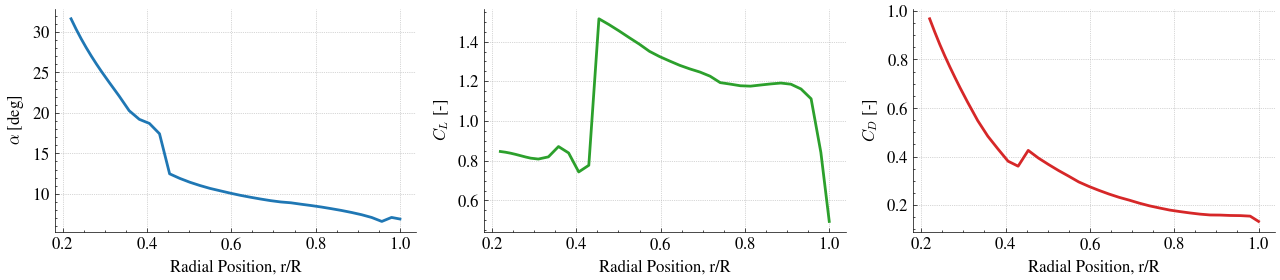

In [8]:
r = sol['r'].to_numpy()
norm_r = r / blade_dict['tip_radius']

fig, axes = plt.subplots(1, 3, figsize=(13, 3))

axes[0].plot(norm_r, sol['alpha'].to_numpy(), linewidth=2, color='tab:blue')
axes[0].set_xlabel('Radial Position, r/R', fontsize=12)
axes[0].set_ylabel('$\\alpha$ [deg]', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=1.0)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].tick_params(top=False, right=False, which='both', labelsize=12)

axes[1].plot(norm_r, sol['Cl'].to_numpy(), linewidth=2, color='tab:green')
axes[1].set_xlabel('Radial Position, r/R', fontsize=12)
axes[1].set_ylabel('$C_L$ [-]', fontsize=12)
axes[1].grid(True, linestyle=':', alpha=1.0)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].tick_params(top=False, right=False, which='both', labelsize=12)

axes[2].plot(norm_r, sol['Cd'].to_numpy(), linewidth=2, color='tab:red')
axes[2].set_xlabel('Radial Position, r/R', fontsize=12)
axes[2].set_ylabel('$C_D$ [-]', fontsize=12)
axes[2].grid(True, linestyle=':', alpha=1.0)
axes[2].spines[['top', 'right']].set_visible(False)
axes[2].tick_params(top=False, right=False, which='both', labelsize=12)

plt.tight_layout()
plt.show()